In [49]:
import pandas as pd
import numpy as np
import string
import seaborn as sns
import matplotlib.pyplot as plt


In [50]:
import nltk
print("NLTK installed successfully")

NLTK installed successfully


In [51]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [52]:
from nltk.corpus import stopwords

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


In [54]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

In [55]:
from wordcloud import WordCloud

In [56]:
df = pd.read_csv("spam.csv", encoding="latin-1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [57]:
df = df[['v1', 'v2']]
df.columns = ['label', 'message']



In [58]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})


In [59]:
print(df.head())
print(df.shape)
print(df['label'].value_counts())

   label                                            message
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...
(5572, 2)
label
0    4825
1     747
Name: count, dtype: int64


In [60]:
df['message'] = df['message'].str.lower()

In [61]:
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

df['message'] = df['message'].apply(remove_punctuation)

In [62]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    words = text.split()
    return " ".join([w for w in words if w not in stop_words])

df['message'] = df['message'].apply(clean_text)

In [63]:
X = df['message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [64]:
tfidf = TfidfVectorizer()

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

In [65]:
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)

y_pred_nb = nb_model.predict(X_test_vec)
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.967713004484305


In [66]:
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall:", recall_score(y_test, y_pred_nb))
print("F1 Score:", f1_score(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.967713004484305
Precision: 1.0
Recall: 0.76
F1 Score: 0.8636363636363636


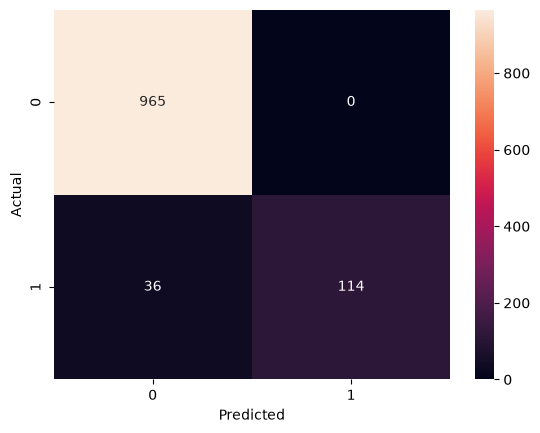

In [67]:
cm = confusion_matrix(y_test, y_pred_nb)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [68]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_vec, y_train)

y_pred_lr = lr_model.predict(X_test_vec)

In [69]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9497757847533632
Precision: 0.9607843137254902
Recall: 0.6533333333333333
F1 Score: 0.7777777777777778


In [70]:
results = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_lr)
    ]
})

print(results)

                 Model  Accuracy
0          Naive Bayes  0.967713
1  Logistic Regression  0.949776


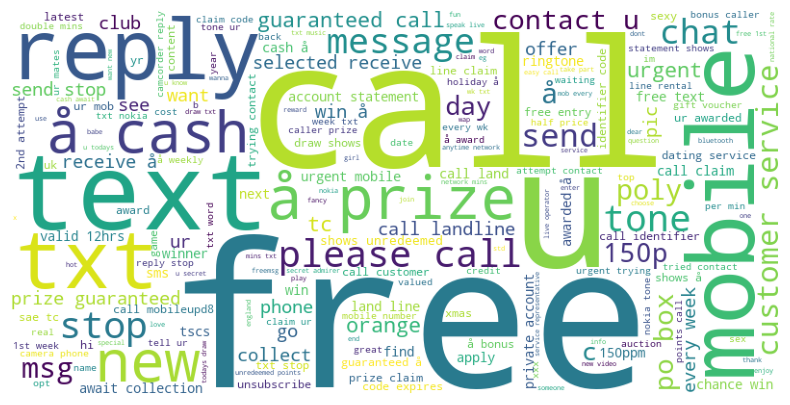

In [71]:
spam_text = " ".join(df[df['label'] == 1]['message'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(spam_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [72]:
msg = ["Congratulations! You won a free iPhone click now"]

msg_vec = tfidf.transform(msg)

prediction = nb_model.predict(msg_vec)

print("Spam" if prediction[0] == 1 else "Ham")

Spam
